In [1]:
import pandas as pd
import numpy as np

try:
    df = pd.read_csv("diabetes_prediction_dataset.csv")
except:
    df = pd.read_excel("diabetes_prediction_dataset.xlsx")

print(f"Dataset Dimensions: {df.shape}")
print(df.head())

Dataset Dimensions: (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [2]:
#data cleaning
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [4]:
#Feature Engineering n Handling Text Columns
print("Data Types:")
print(df.dtypes)

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)
print(df_encoded.head())

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   diabetes  gender_Male  gender_Other  smoking_history_current  \
0         0            0             0                        0   
1         0            0             0                        0   
2      

In [6]:
#Data Split & Feature Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=['diabetes'])
Y = df_encoded['diabetes']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
#Training the Logistic Regression Model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
#Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Y_pred = log_model.predict(X_test_scaled)

acc = accuracy_score(Y_test, Y_pred)
print(f"Overall Classification Accuracy: {acc * 100:.2f}%\n")
print(classification_report(Y_test, Y_pred))

Overall Classification Accuracy: 95.91%

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



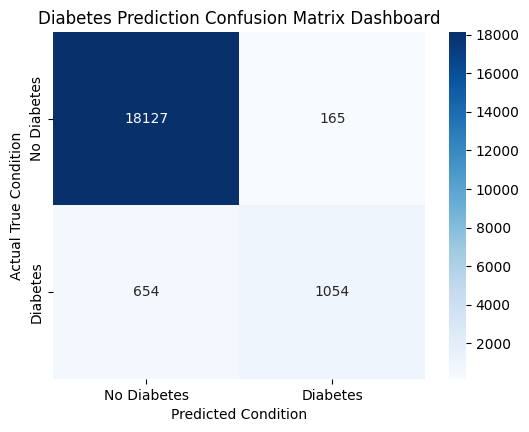

In [11]:
#Confusion Matrix Visualization
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])

plt.xlabel("Predicted Condition")
plt.ylabel("Actual True Condition")
plt.title("Diabetes Prediction Confusion Matrix Dashboard")
plt.show()